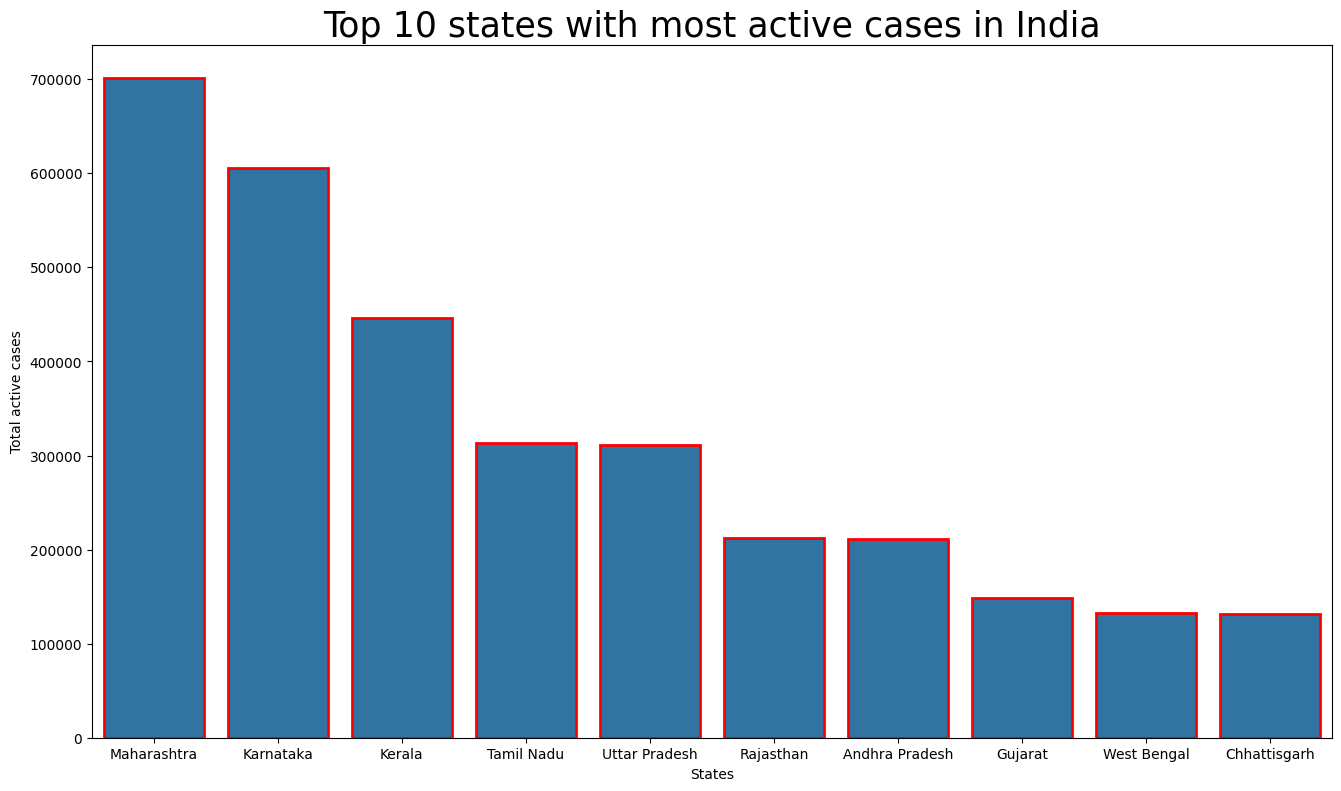

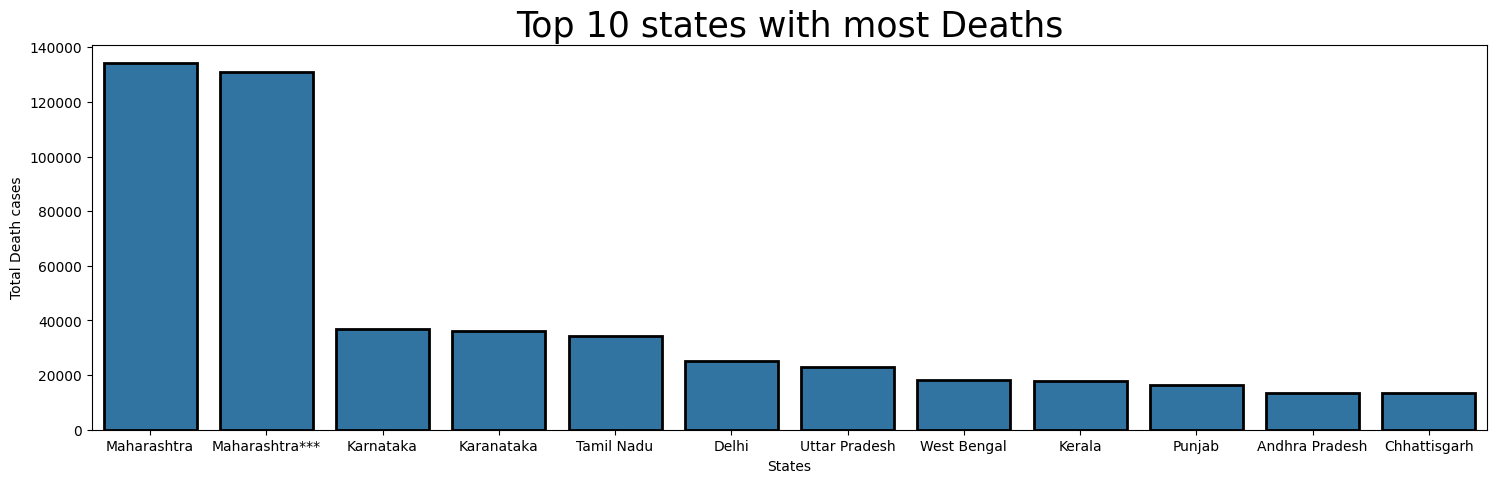

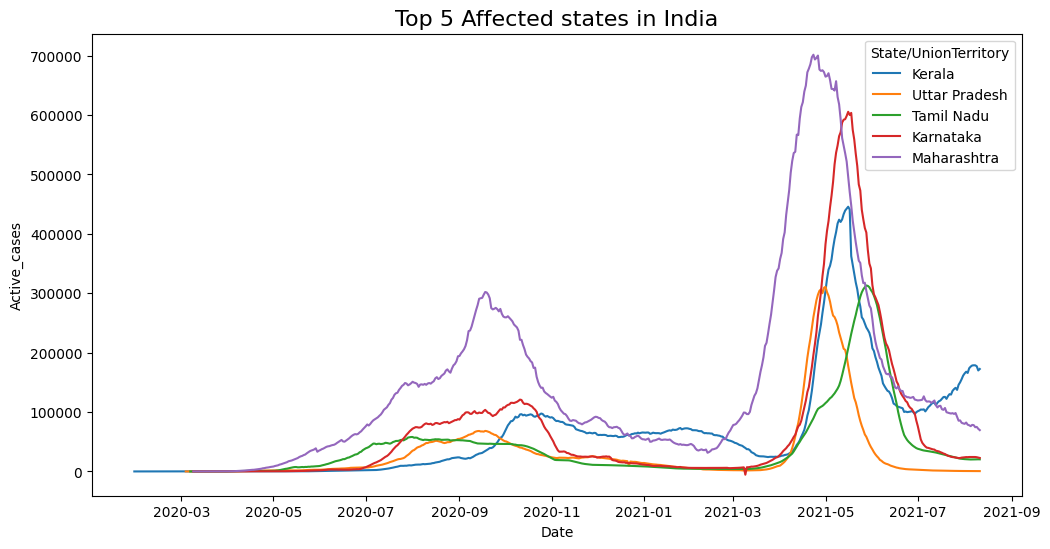

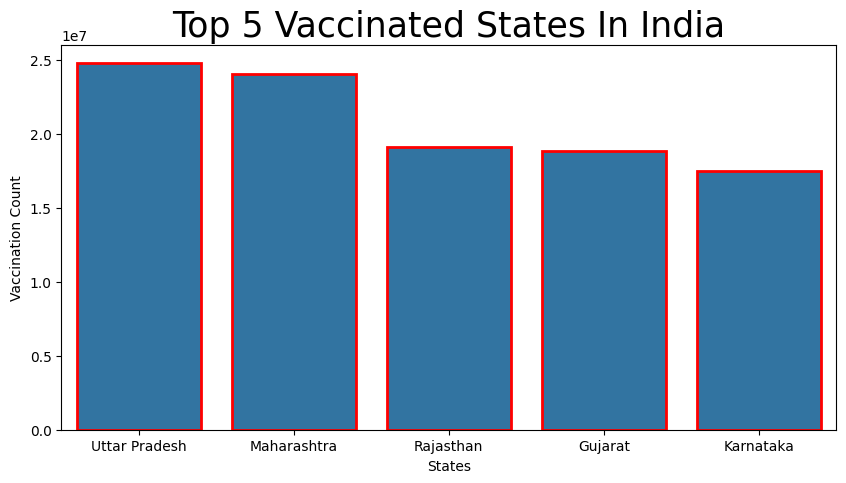

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
from datetime import datetime

covid_df = pd.read_csv('dataset/data.csv')
vaccine_df = pd.read_csv('dataset/data2.csv')

covid_df.drop(["Sno", "Time", "ConfirmedIndianNational", "ConfirmedForeignNational"], inplace=True, axis=1)

covid_df['Date'] = pd.to_datetime(covid_df['Date'], format='%Y-%m-%d')

covid_df['Active_cases'] = covid_df['Confirmed'] - (covid_df['Cured'] + covid_df['Deaths'])

statewise = pd.pivot_table(covid_df, values=["Confirmed", "Deaths", "Cured"], index="State/UnionTerritory", aggfunc="max")
statewise["Recovery Rate"] = statewise["Cured"] * 100 / statewise["Confirmed"]
statewise["Mortality Rate"] = statewise["Deaths"] * 100 / statewise["Confirmed"]
statewise = statewise.sort_values(by="Confirmed", ascending=False)

top_10_active_cases = covid_df.sort_values(by='Active_cases', ascending=False).drop_duplicates(['State/UnionTerritory']).reset_index(drop=True)

fig1 = plt.figure(figsize=(16, 9))
plt.title("Top 10 states with most active cases in India", size=25)
ax1 = sns.barplot(data=top_10_active_cases.iloc[:10], y="Active_cases", x="State/UnionTerritory", linewidth=2, edgecolor='red')
plt.xlabel("States")
plt.ylabel("Total active cases")
plt.show()

top_10_deaths = covid_df.sort_values(by='Deaths', ascending=False).drop_duplicates(['State/UnionTerritory']).reset_index(drop=True)

fig2 = plt.figure(figsize=(18, 5))
plt.title("Top 10 states with most Deaths", size=25)
ax2 = sns.barplot(data=top_10_deaths.iloc[:12], y="Deaths", x="State/UnionTerritory", linewidth=2, edgecolor="black")
plt.xlabel("States")
plt.ylabel("Total Death cases")
plt.show()

fig3 = plt.figure(figsize=(12, 6))
top_5_states = ['Maharashtra', 'Karnataka', 'Kerala', 'Tamil Nadu', 'Uttar Pradesh']
ax3 = sns.lineplot(data=covid_df[covid_df['State/UnionTerritory'].isin(top_5_states)], x='Date', y='Active_cases', hue='State/UnionTerritory')
ax3.set_title("Top 5 Affected states in India", size=16)
plt.show()

vaccine_df.rename(columns={'Updated On': 'Vaccine_Date'}, inplace=True)

vaccination = vaccine_df.drop(columns=['Sputnik V (Doses Administered)', 'AEFI', '18-44 Years (Doses Administered)', '45-60 Years (Doses Administered)', '60+ Years (Doses Administered)'], axis=1)

state_totals = vaccine_df[vaccine_df['State'] != 'India'].groupby('State').max()
male = state_totals["Male (Doses Administered)"].sum()
female = state_totals["Female (Doses Administered)"].sum()

fig_pie = px.pie(names=["Male", "Female"], values=[male, female], title="Male and Female Vaccination Split")
fig_pie.show()

vaccine = vaccine_df[vaccine_df.State != 'India'].copy()
vaccine.rename(columns={"Total Individuals Vaccinated": 'Total'}, inplace=True)

max_vac = vaccine.groupby('State')['Total'].max().to_frame('Total')
max_vac = max_vac.sort_values('Total', ascending=False)[:5]

fig4 = plt.figure(figsize=(10, 5))
plt.title("Top 5 Vaccinated States In India", size=25)
ax4 = sns.barplot(data=max_vac, y=max_vac.Total, x=max_vac.index, linewidth=2, edgecolor='red')
plt.xlabel("States")
plt.ylabel("Vaccination Count")
plt.show()